# 1. Necessary Imports

In [1]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


start_date = "2019-01-01"
end_date = "2024-01-01"

#functions
from src.portfolio_stats import calculate_volatility, calculate_max_drawdown, calculate_mean_portfolio_returns, calculate_sharpe_ratio, calculate_cagr, calculate_return_path

#data
data = pd.read_csv("data/prices.csv", index_col="Date", parse_dates=True)

from data_loader import read_rfr
rfr = read_rfr(start_date, end_date)


#checking data
print(rfr)
print(data.head())

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

0.022721041324881567
                 AAPL        BND        EEM         GLD        JPM  \
Date                                                                 
2019-01-02  37.503727  64.321159  33.319092  121.330002  81.250206   
2019-01-03  33.768082  64.572395  32.714993  122.430000  80.095512   
2019-01-04  35.209618  64.377914  33.770039  121.440002  83.048241   
2019-01-07  35.131241  64.280693  33.846615  121.860001  83.105972   
2019-01-08  35.800949  64.199638  33.974239  121.529999  82.949272   

                   SPY        TSM        XOM  
Date                                          
2019-01-02  224.995285  31.237246  50.001846  
2019-01-03  219.626328  29.389700  49.234135  
2019-01-04  226.982849  29.911469  51.049358  
2019-01-07  228.772507  30.133842  51.314846  
2019-01-08  230.921906  29.885798  51.687946  


# 2. Equal Weights

## 2.1. Returns:

In [2]:
#LOG VS SIMPLE TEST
initial_capital = 10000
equal_weights = np.array([1/data.columns.size] * data.columns.size)
equal_weights

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

In [3]:
simple_returns = data.pct_change().dropna()
simple_returns

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,-0.099607,0.003906,-0.018131,0.009066,-0.014212,-0.023863,-0.059146,-0.015354
2019-01-04,0.042689,-0.003012,0.032250,-0.008086,0.036865,0.033496,0.017753,0.036869
2019-01-07,-0.002226,-0.001510,0.002268,0.003458,0.000695,0.007885,0.007434,0.005201
2019-01-08,0.019063,-0.001261,0.003771,-0.002708,-0.001886,0.009395,-0.008231,0.007271
2019-01-09,0.016981,0.001388,0.017781,0.006418,-0.001690,0.004674,0.019176,0.005275
...,...,...,...,...,...,...,...,...
2023-12-22,-0.005547,-0.000668,-0.004802,0.004434,-0.000597,0.002010,0.005851,0.001769
2023-12-26,-0.002841,0.000955,0.007872,0.007621,0.005914,0.004223,0.012603,0.002257
2023-12-27,0.000518,0.006400,0.005795,0.004538,0.005998,0.001808,0.001915,-0.004699


In [4]:
daily_simple_returns = np.dot(simple_returns, equal_weights)
print(daily_simple_returns)
print()
print(daily_simple_returns.shape)

[-0.02716741  0.02360303  0.00290058 ...  0.00278413 -0.00081887
 -0.00283066]

(1257,)


In [5]:
#wealth path:
wealth_simple = initial_capital * (1 + daily_simple_returns).cumprod()
wealth_simple

array([ 9728.32590292,  9957.94387178,  9986.82764794, ...,
       21953.96156748, 21935.98410736, 21873.89079725], shape=(1257,))

In [6]:
# czyli jak mam log returns to sposob przejscia w faktyczny return jest troche inny - bo mam zagwarantwana addytywnosc w czasie,
# ale nie mam zagwarantowanej addytywnosci miedzy poszczegolnymi aktywami,
# wiec zeby to obejsc biore returns miedzy aktywami z simple, i potem zmieniam recznie na log. inaczej nie przeskocze chyba.
# wiec simple returns lepiej tutaj chyba wykorzystac. nie zyskuje nic z logow.
# robienie log_returns = np.log(data/data.shift(1)) mija sie z celem bo calego portfela tutaj nie zlicze.

In [7]:
df = pd.Series(wealth_simple, index=(data.index[1:]))
print(df)
print()

Date
2019-01-03     9728.325903
2019-01-04     9957.943872
2019-01-07     9986.827648
2019-01-08    10018.553173
2019-01-09    10106.219184
                  ...     
2023-12-22    21787.876347
2023-12-26    21893.008590
2023-12-27    21953.961567
2023-12-28    21935.984107
2023-12-29    21873.890797
Length: 1257, dtype: float64



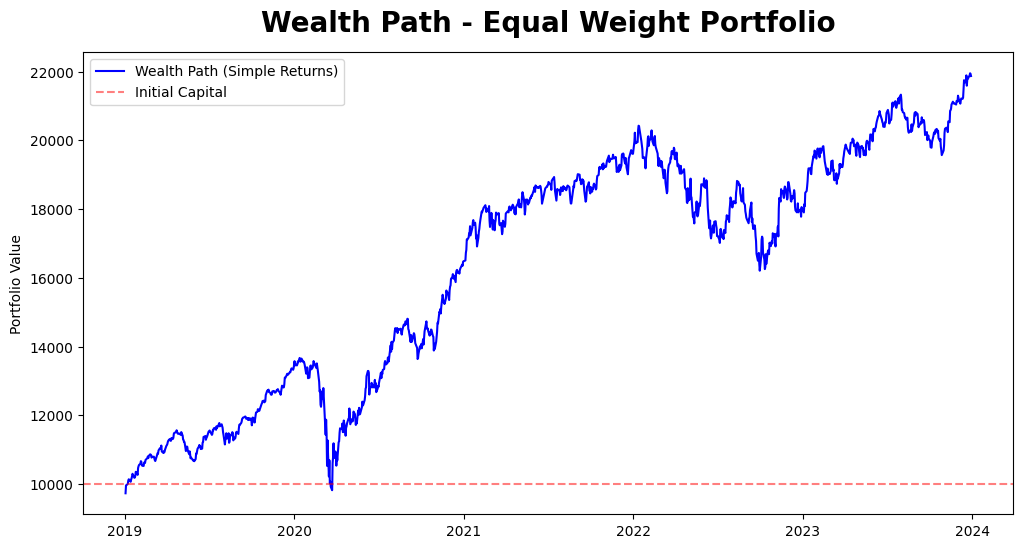

In [8]:
#vizing the wealth path.
plt.figure(figsize=(12, 6))
plt.plot(df, label='Wealth Path (Simple Returns)', color='blue')
plt.axhline(y=initial_capital, color='red', linestyle='--', alpha=0.5, label='Initial Capital')
plt.title('Wealth Path - Equal Weight Portfolio', fontsize=20, pad=15, fontweight='bold')
plt.ylabel('Portfolio Value')
plt.legend()

## 2.2. Stats/Analysis

In [9]:
eq_portfolio_returns = simple_returns @ equal_weights # equivalent to np.dot(simple_returns, equal_weights)
eq_portfolio_returns

Date
2019-01-03   -0.027167
2019-01-04    0.023603
2019-01-07    0.002901
2019-01-08    0.003177
2019-01-09    0.008750
                ...   
2023-12-22    0.000306
2023-12-26    0.004825
2023-12-27    0.002784
2023-12-28   -0.000819
2023-12-29   -0.002831
Length: 1257, dtype: float64

In [10]:
# annualized average return rate
trading_days = 252

annualized_average_return_rate = eq_portfolio_returns.mean() * trading_days
annualized_average_return_rate


np.float64(0.1730098481900031)

In [11]:
total_return_rate = (1 + eq_portfolio_returns).cumprod() - 1
total_return_rate

Date
2019-01-03   -0.027167
2019-01-04   -0.004206
2019-01-07   -0.001317
2019-01-08    0.001855
2019-01-09    0.010622
                ...   
2023-12-22    1.178788
2023-12-26    1.189301
2023-12-27    1.195396
2023-12-28    1.193598
2023-12-29    1.187389
Length: 1257, dtype: float64

In [12]:
# volatility

# daily variance
print("daily variance:",eq_portfolio_returns.var())

# annualized variance
print("annalized variance", eq_portfolio_returns.var() * trading_days)

# annualized volatility
annualized_volatility = np.sqrt(eq_portfolio_returns.var() * trading_days)
print("annualized volatility", annualized_volatility)

daily variance: 0.00012687367808493928
annalized variance 0.0319721668774047
annualized volatility 0.17880762533349828


## 2.3. Equal Weight Portfolio Stats:

In [13]:
stats = {
    "Volatility (std)": calculate_volatility(equal_weights, data),
    "Mean Log Return": calculate_mean_portfolio_returns(equal_weights, data),
    "CAGR": calculate_cagr(equal_weights, data),
    "Sharpe Ratio": calculate_sharpe_ratio(equal_weights, data),
    "Max Drawdown": calculate_max_drawdown(equal_weights, data)
}

#table
print("-" * 30)
print(f"{'PORTFOLIO METRIC':<20} | {'VALUE':>8}")
print("-" * 30)
for metric, value in stats.items():
    if "Sharpe" in metric:
        print(f"{metric:<20} | {value:>8.4f}")
    else:
        print(f"{metric:<20} | {value:>7.2%}")
print("-" * 30)

return_path = calculate_return_path(equal_weights, data)
print("\nReturn Path (Head):")
print(return_path[:10])

------------------------------
PORTFOLIO METRIC     |    VALUE
------------------------------
Volatility (std)     |  17.88%
Mean Log Return      |  17.30%
CAGR                 |  16.98%
Sharpe Ratio         |   0.8405
Max Drawdown         |  28.17%
------------------------------

Return Path (Head):
[       nan 0.97283259 0.99579439 0.99868276 1.00185532 1.01062192
 1.01358987 1.01172565 1.00639492 1.01306054]


## 2.4. Equal Weight Portfolio - Returns vs Drawdowns

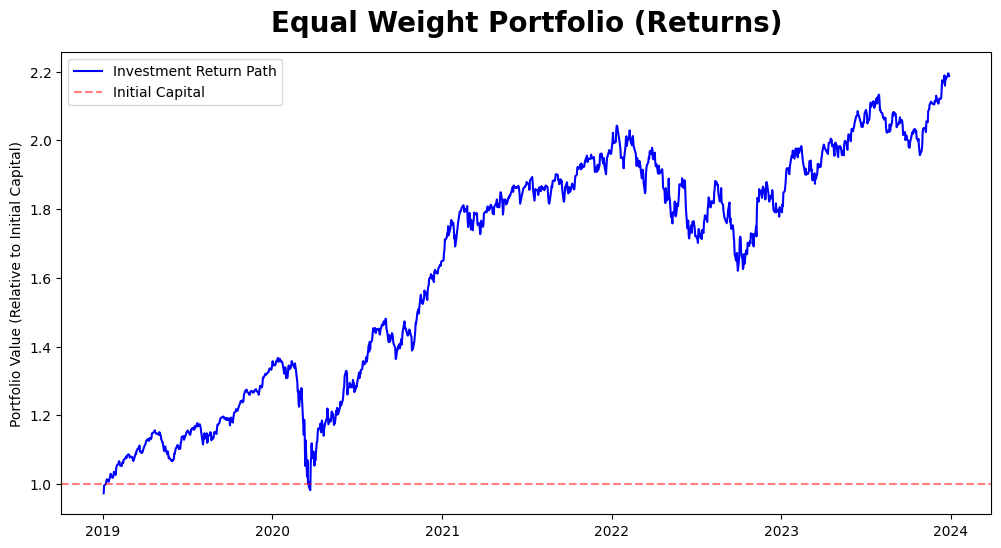

Total Return: 118.74%


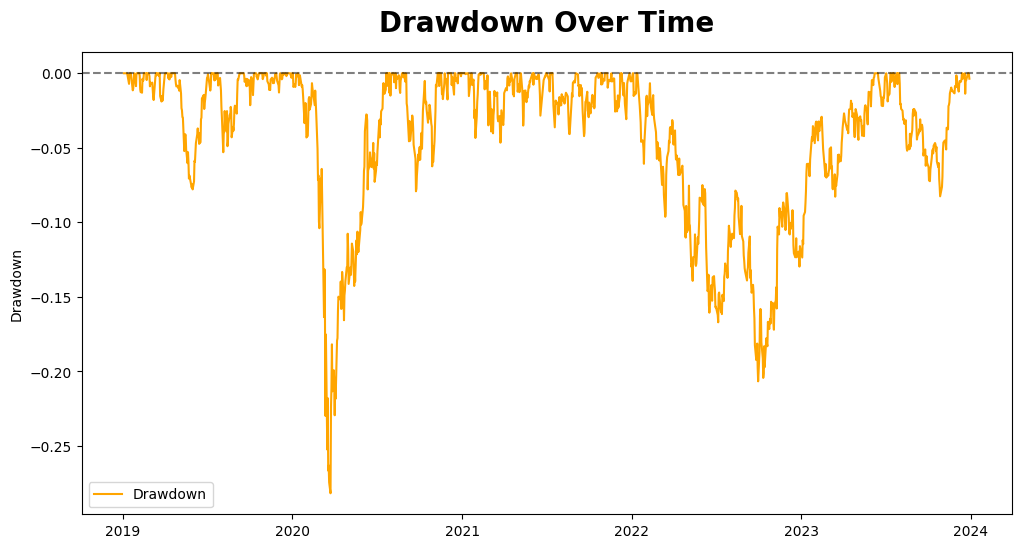

Maximum Drawdown: -28.17%


In [14]:
from src.vizualizations import plot_return_and_drawdown
plot_return_and_drawdown(equal_weights, data)